In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns

import os
from tqdm import tqdm

In [2]:
POSTS_DIR = 'data/dataframe'

files_name = os.listdir(POSTS_DIR)

post_1_ind = 20
post_2_ind = 12

post_1_data = pd.read_csv(os.path.join(POSTS_DIR,files_name[post_1_ind]))
post_2_data = pd.read_csv(os.path.join(POSTS_DIR,files_name[post_2_ind]))

In [3]:
files_name

['MAKH.csv',
 'ANZALI.csv',
 'KBG.csv',
 'ASHOR.csv',
 'CHELEKEN.csv',
 'BEK.csv',
 'SUMG.csv',
 'NEKA.csv',
 'KUL.csv',
 'TUL.csv',
 'JILOYChilov.csv',
 'KRASN.csv',
 'BAKU.csv',
 'KUULI.csv',
 'NOUSHAR.csv',
 'OGUR.csv',
 'LEN.csv',
 'F_KENAR.csv',
 'NKAMNI.csv',
 'LAG.csv',
 'AKTAU.csv',
 'PESH.csv',
 'FORT.csv',
 'ISB.csv']

In [4]:
posts_dir = {
    'AKTAU.csv': 'Aktau', 
    'ANZALI.csv': 'Anzali', 
    'ASHOR.csv': 'Ashuradeh', 
    'BAKU.csv': 'Baku', 
    'BEK.csv': 'Bekdash', 
    'CHELEKEN.csv': 'Cheleken', 
    'F_KENAR.csv': 'Fereydunkenar', 
    'FORT.csv': 'Fort-Shevchenko', 
    'ISB.csv': 'Izberbash', 
    'JILOYChilov.csv': 'Isl. Jiloy', 
    'KBG.csv': 'Kara-Bogaz-Gol', 
    'KRASN.csv': 'Krasnovodsk', 
    'KUL.csv': 'Kulaly', 
    'KUULI.csv': 'Kuuli-Mayak', 
    'LAG.csv': 'Lagan', 
    'LEN.csv': 'Lankaran', 
    'MAKH.csv': 'Makhachkala', 
    'NEKA.csv': 'Neka', 
    'NKAMNI.csv': 'Neftyanye Kamni', 
    'NOUSHAR.csv': 'Nowshahr', 
    'OGUR.csv': 'Ogurchinskiy', 
    'PESH.csv': 'Peshnoy', 
    'SUMG.csv': 'Sumgait', 
    'TUL.csv': 'Isl. Tyuleniy'
}

In [5]:
post_ind = [posts_dir[item] for item in files_name]

In [6]:
post_1_data['datetime'] = pd.to_datetime(post_1_data['datetime'])
post_1_data['sea_level'] = pd.to_numeric(post_1_data['sea_level'], errors='coerce')

post_2_data['datetime'] = pd.to_datetime(post_2_data['datetime'])
post_2_data['sea_level'] = pd.to_numeric(post_2_data['sea_level'], errors='coerce')

/tmp/ipykernel_5795/897010239.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  post_1_data['datetime'] = pd.to_datetime(post_1_data['datetime'])
/tmp/ipykernel_5795/897010239.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  post_2_data['datetime'] = pd.to_datetime(post_2_data['datetime'])


In [7]:
width = 75
height = 65

plt.rcParams.update({
    'font.family': 'sans-serif',  # 'sans-serif' 'serif'
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'lines.linewidth': 0.8,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,

    'grid.linewidth': 0.4,
    'grid.alpha': 0.7,   
    'grid.linestyle': '--',
})

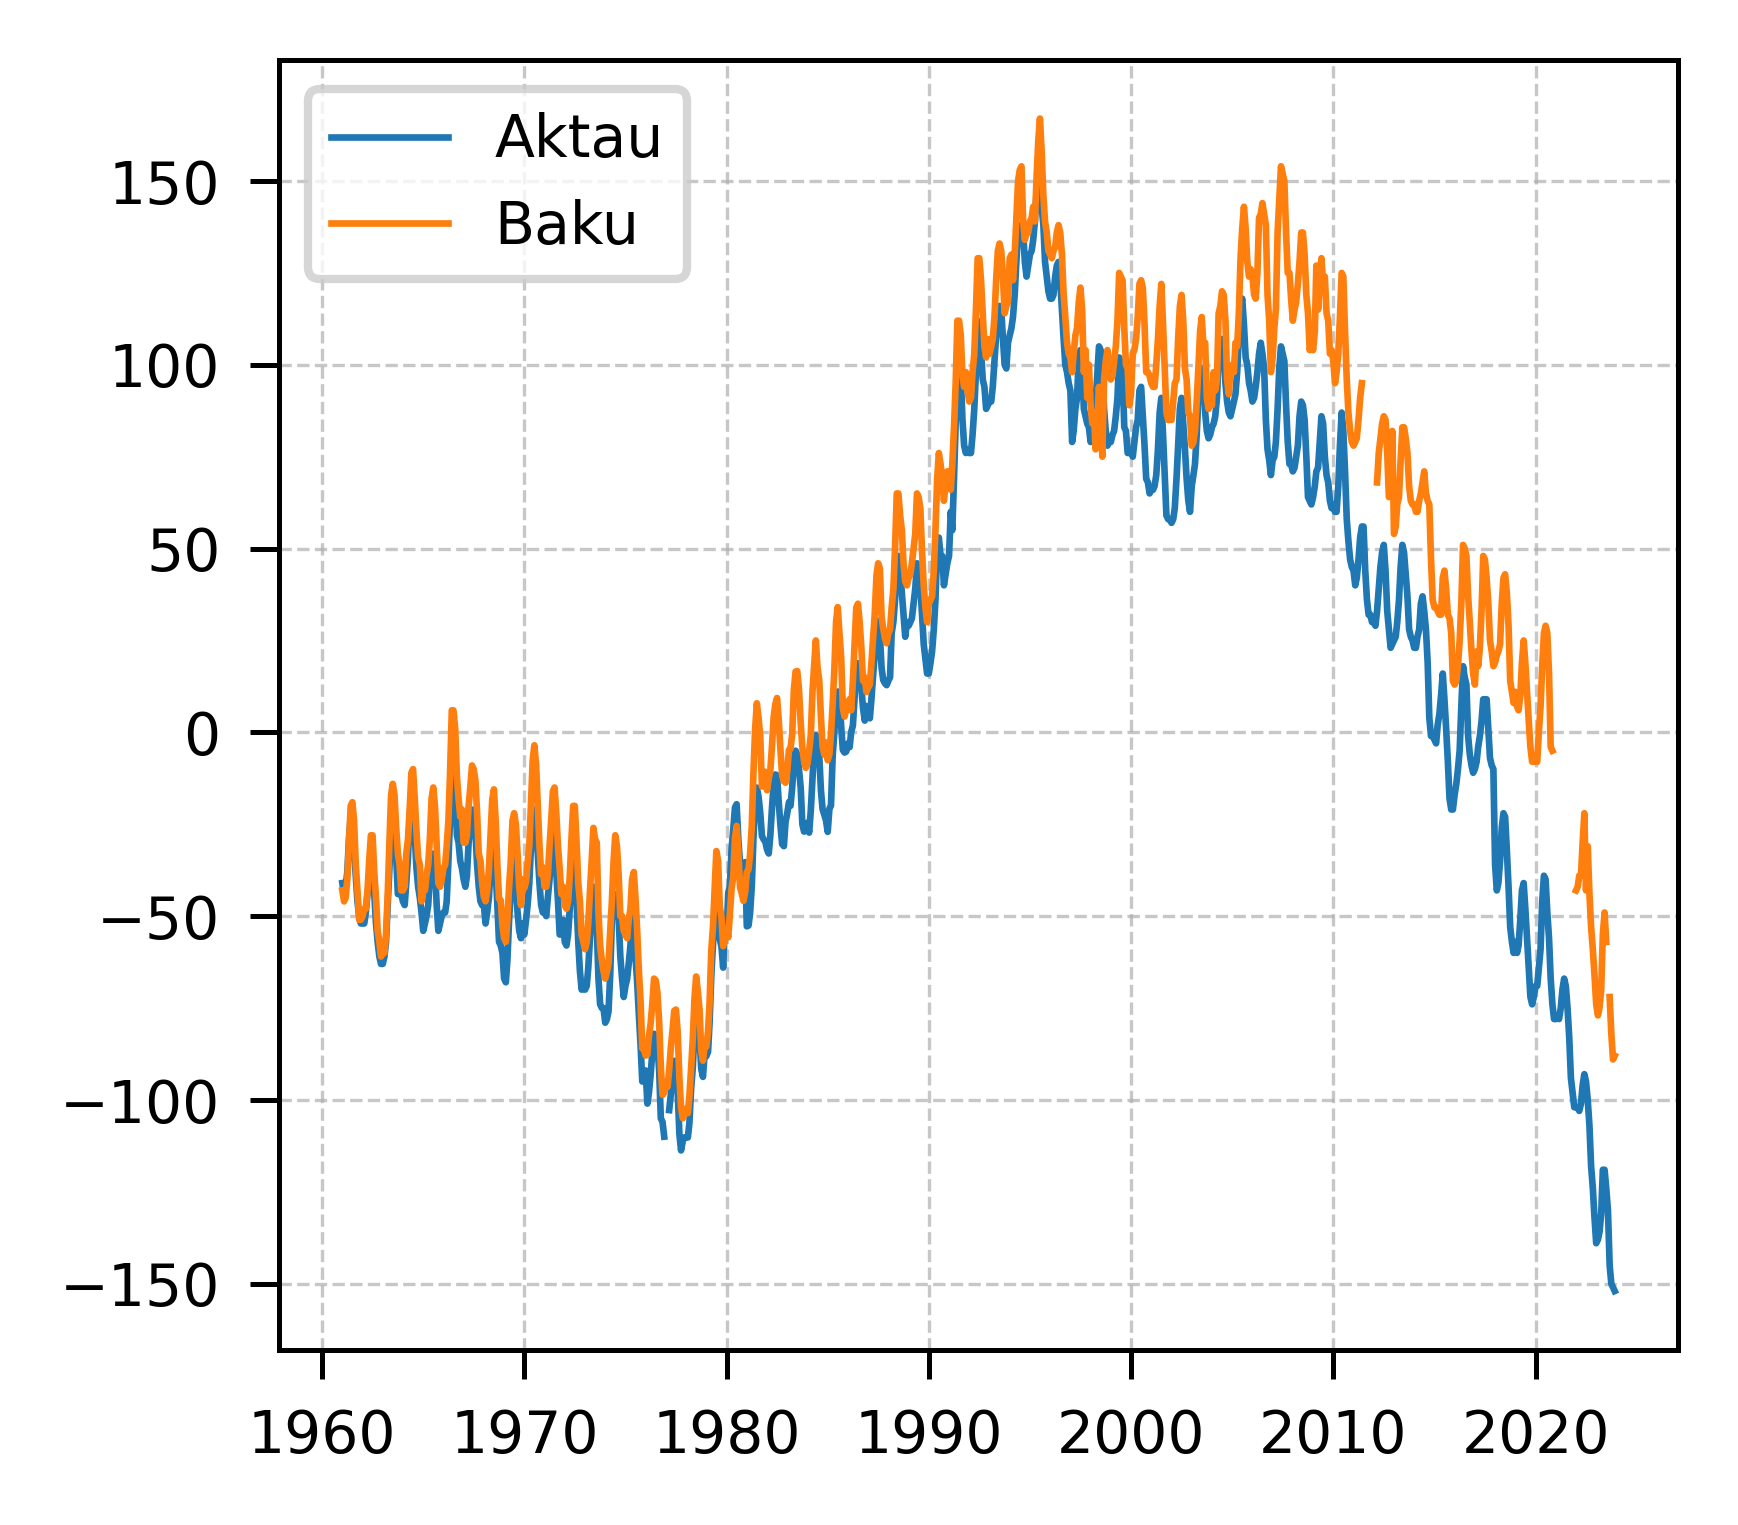

In [8]:
fig = plt.figure(figsize=(width/25.4, height/25.4), dpi=600)
ax = fig.add_subplot(111)

fig.subplots_adjust(
    left=0.2,
    right=0.99,
    bottom=0.15,
    top=0.99
)

t_0 = max(post_1_data['datetime'].min(), post_2_data['datetime'].min())

ax.plot(post_1_data[post_1_data['datetime']>=t_0]['datetime'], post_1_data[post_1_data['datetime']>=t_0]['sea_level'], label=post_ind[post_1_ind])
ax.plot(post_2_data[post_2_data['datetime']>=t_0]['datetime'], post_2_data[post_2_data['datetime']>=t_0]['sea_level'], label=post_ind[post_2_ind])

ax.legend()
ax.grid(True)

plt.savefig('figure_2.png', format='png', dpi=600)
plt.show()

plt.close()

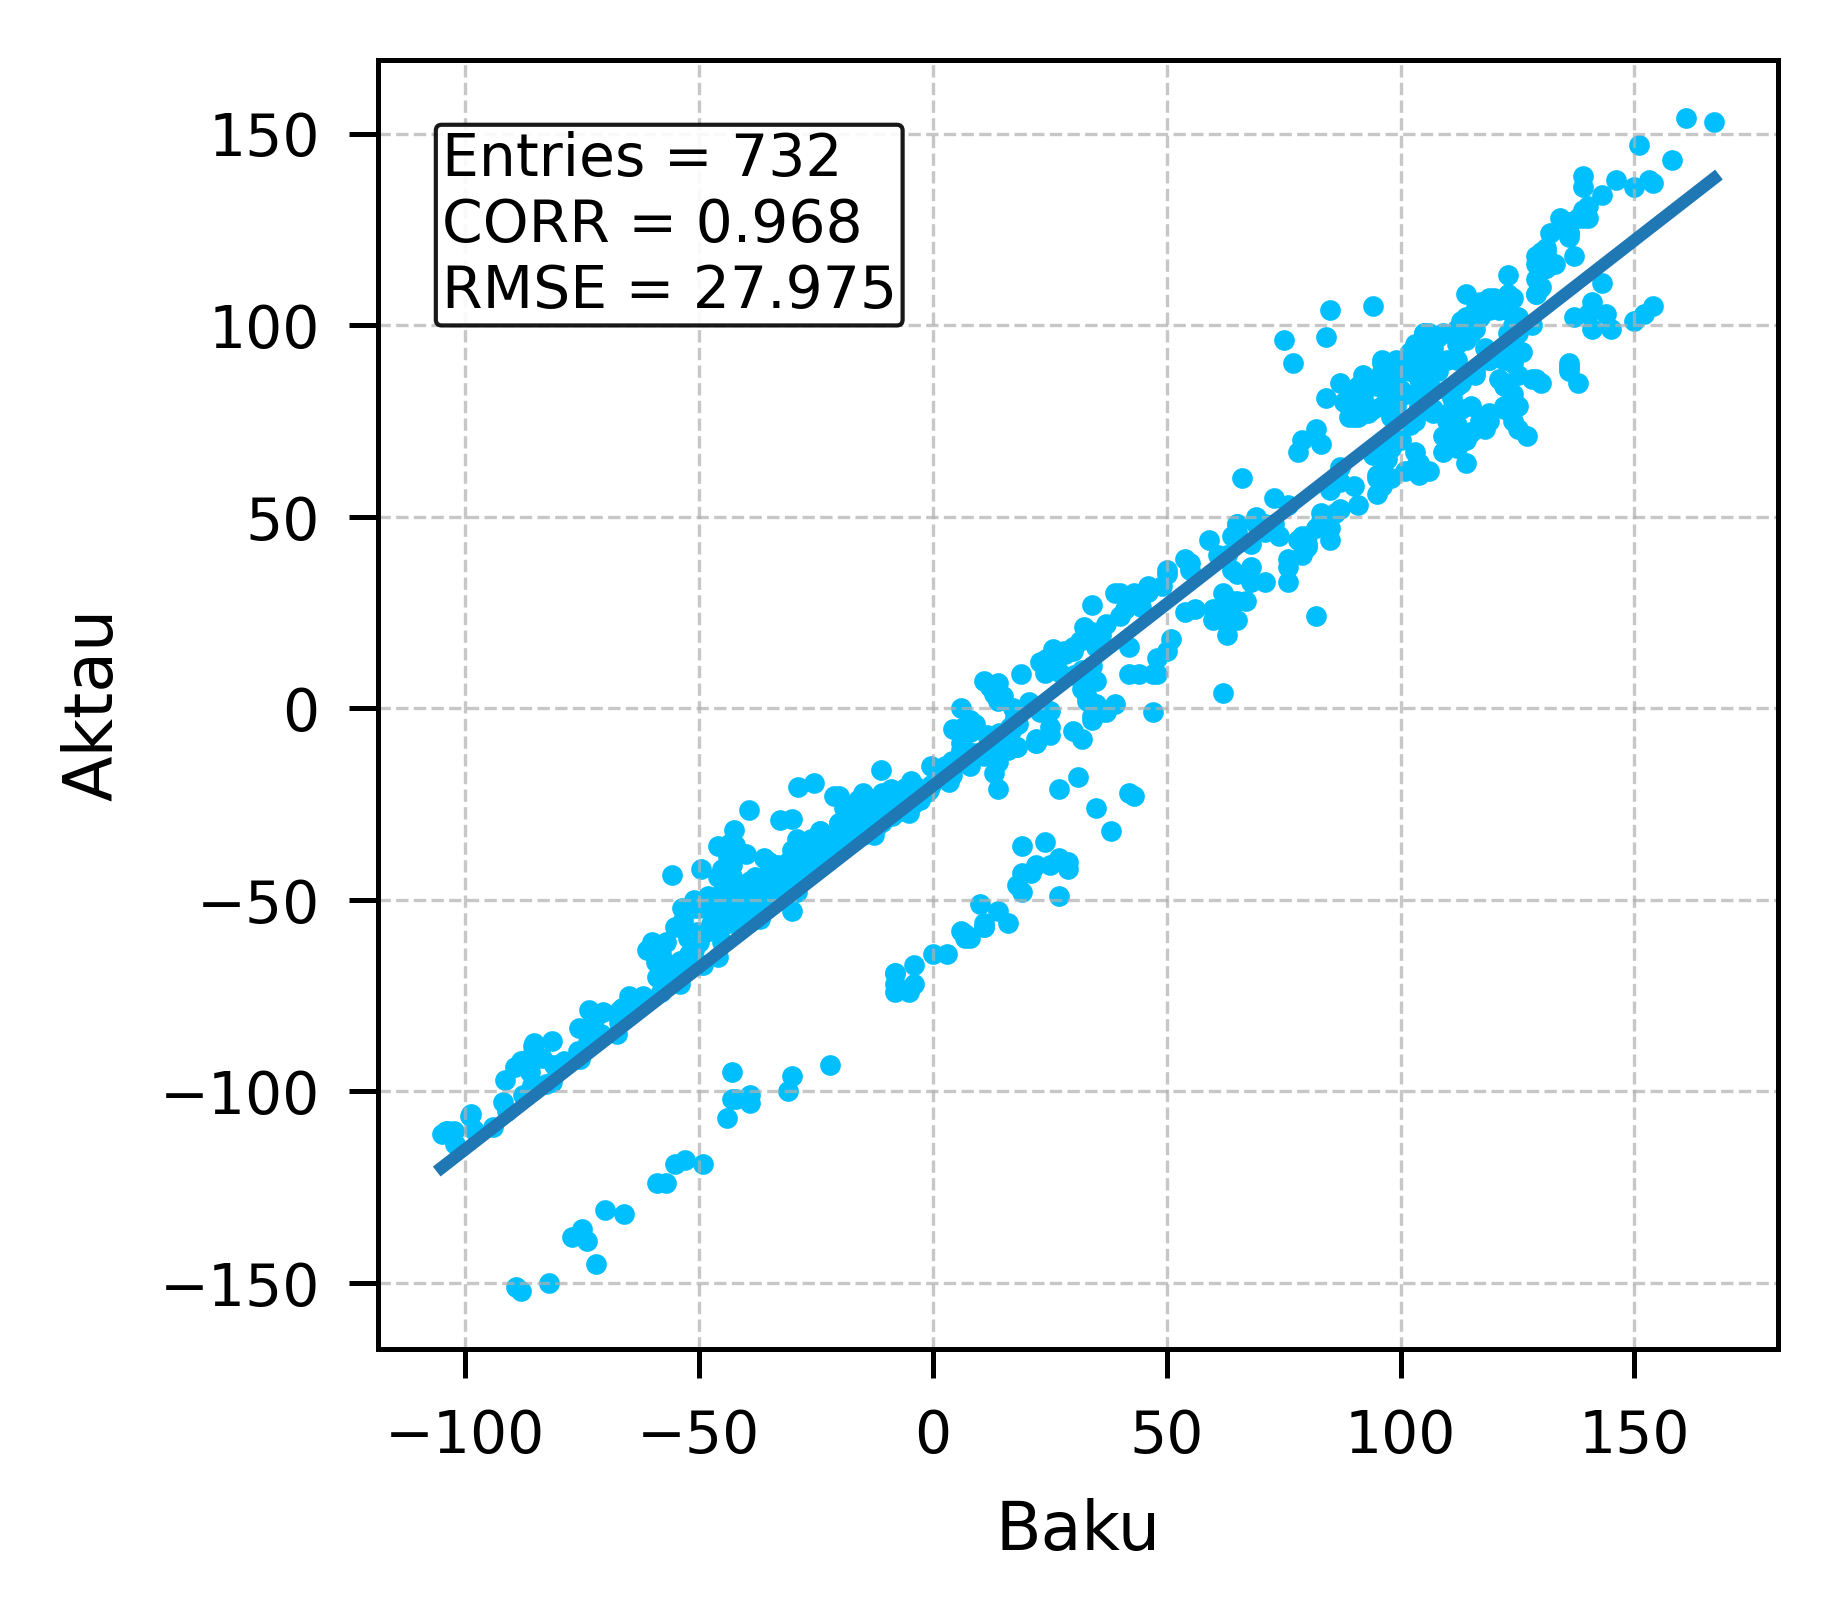

In [11]:
from sklearn.linear_model import LinearRegression

def stat(x: np.ndarray, y: np.ndarray):
    assert len(x)==len(y)
    mu_x = np.mean(x)
    mu_y = np.mean(y)

    m = LinearRegression().fit(x.values.reshape(-1, 1),y.values.reshape(-1, 1))
    a = m.coef_[0,0]
    b = m.intercept_[0]

    me = np.mean(y-x)
    sd = np.sqrt(np.sum((y-x-me)**2)/(len(x)-1))
    rmse = np.sqrt(me**2+sd**2)

    corr = np.mean((x-mu_x)*(y-mu_y))/np.sqrt(np.mean((x-mu_x)**2)*np.mean((y-mu_y)**2))

    return {
        'entries': len(x),
        'corr': corr,
        'rmse': rmse,
        'a': a,
        'b': b
    }

fig = plt.figure(figsize=(width/25.4, height/25.4), dpi=600)
ax = fig.add_subplot(111)

fig.subplots_adjust(
    left=0.2,
    right=0.99,
    bottom=0.15,
    top=0.99
)

df_dummy = pd.merge(post_1_data, post_2_data, on='datetime', suffixes=('_post1', '_post2')).dropna()
ax.scatter(df_dummy['sea_level_post2'], df_dummy['sea_level_post1'], s=2.2, color=[0, 191/255, 255/255])

statistics = stat(df_dummy['sea_level_post2'], df_dummy['sea_level_post1'])
x_min_ = np.min(df_dummy['sea_level_post2'])
x_max_ = np.max(df_dummy['sea_level_post2'])
y_min_ = np.min(df_dummy['sea_level_post1'])
y_max_ = np.max(df_dummy['sea_level_post1'])
ax.plot([x_min_, x_max_],[x_min_*statistics['a']+statistics['b'], x_max_*statistics['a']+statistics['b']], linewidth=1.5)

if((width==75) and (height==65)):
    d_ = y_max_ - y_min_
    delta_ = d_/13
    text_str = f"Entries = {statistics['entries']}\nCORR = {statistics['corr']:.3f}\nRMSE = {statistics['rmse']:.3f}"
    plt.text(x_min_, y_max_-2.1*delta_, 
            text_str,
            bbox=dict(boxstyle='round,pad=0.1', 
                    facecolor='white', 
                    alpha=0.9, 
                    edgecolor='black',
                    linewidth=0.5), size=7.0)

plt.xlabel(post_ind[post_2_ind])
plt.ylabel(post_ind[post_1_ind])

plt.grid(True)

plt.savefig('figure_3.png', format='png', dpi=600)
plt.show()

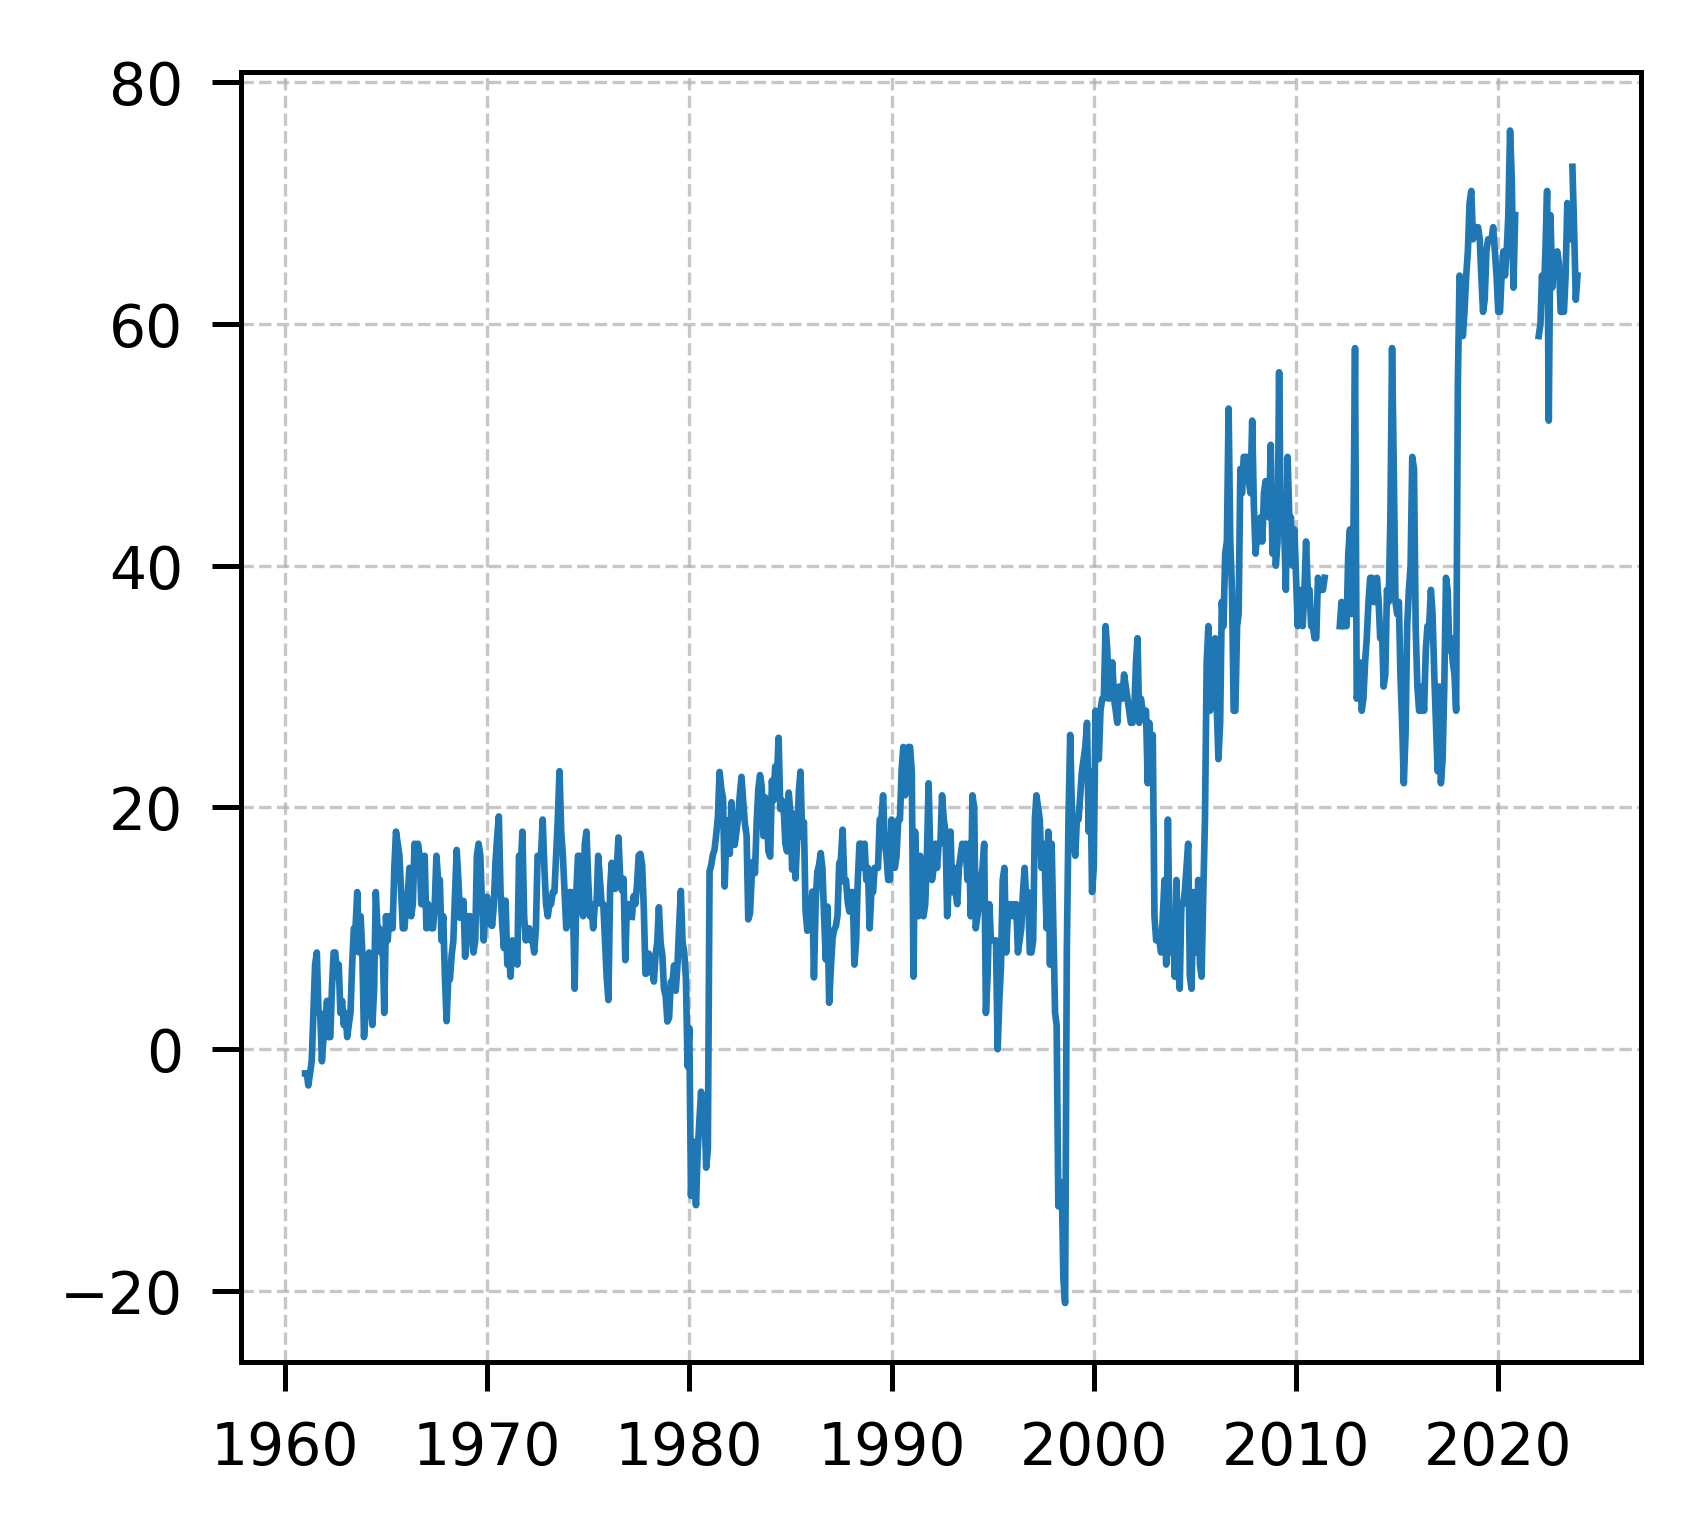

In [10]:
fig = plt.figure(figsize=(width/25.4, height/25.4), dpi=600)
ax = fig.add_subplot(111)

fig.subplots_adjust(
    left=0.2,
    right=0.99,
    bottom=0.15,
    top=0.99
)

df_dummy = pd.merge(post_1_data, post_2_data, on='datetime', suffixes=('_post1', '_post2'))
ax.plot(df_dummy['datetime'], df_dummy['sea_level_post2'] - df_dummy['sea_level_post1'])

ax.grid(True)

plt.savefig('figure_4.png', format='png', dpi=600)
plt.show()